In [5]:
# ==========================================================
# IPL MATCHES DATASET - DATA CLEANING AND EDA
# Using NumPy, Pandas and Matplotlib
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()


Saving matches.csv to matches.csv


Dataset Loaded Successfully!
Shape of Dataset: (756, 18)
Missing values before cleaning:
id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

Missing values after cleaning:
id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

Summary Statistics:
                 id       season  dl_applied  win_by_runs  wi

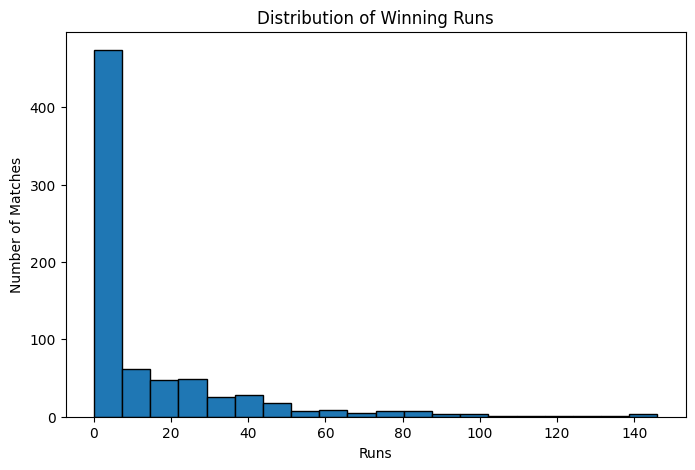


Correlation Matrix:
                  season  dl_applied  win_by_runs  win_by_wickets
season          1.000000   -0.001116    -0.037529       -0.009379
dl_applied     -0.001116    1.000000    -0.016349       -0.011631
win_by_runs    -0.037529   -0.016349     1.000000       -0.560420
win_by_wickets -0.009379   -0.011631    -0.560420        1.000000


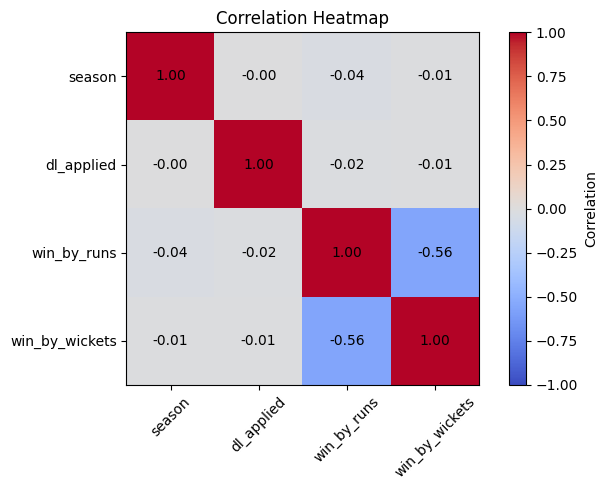

In [8]:
# ==========================================================
# 1. LOAD DATASET
# ==========================================================

matches = pd.read_csv("matches.csv")

print("Dataset Loaded Successfully!")
print("Shape of Dataset:", matches.shape)


# ==========================================================
# 2. DATASET INFORMATION
# ==========================================================

# ==================================================
# 1. HANDLING MISSING VALUES
# ==================================================

print("Missing values before cleaning:")
print(matches.isnull().sum())

# Remove column with many missing values
matches = matches.drop(columns=["umpire3"])

# Fill missing categorical values
matches["city"] = matches["city"].fillna("Unknown")
matches["winner"] = matches["winner"].fillna("Unknown")
matches["player_of_match"] = matches["player_of_match"].fillna("Unknown")
matches["umpire1"] = matches["umpire1"].fillna("Unknown")
matches["umpire2"] = matches["umpire2"].fillna("Unknown")

print("\nMissing values after cleaning:")
print(matches.isnull().sum())


# ==================================================
# 2. SUMMARY STATISTICS
# ==================================================

print("\nSummary Statistics:")
print(matches.describe())


# ==================================================
# 3. DISTRIBUTION PLOT
# ==================================================

plt.figure(figsize=(8, 5))

plt.hist(
    matches["win_by_runs"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Winning Runs")
plt.xlabel("Runs")
plt.ylabel("Number of Matches")

plt.show()


# ==================================================
# 4. CORRELATION PLOT
# ==================================================

# Select numerical columns
numeric_data = matches[
    ["season", "dl_applied", "win_by_runs", "win_by_wickets"]
]

correlation = numeric_data.corr()

print("\nCorrelation Matrix:")
print(correlation)


# Plot correlation heatmap
plt.figure(figsize=(7, 5))

plt.imshow(
    correlation,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

# Display correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()